# 03 - Modelado

## Predicción de Alertas de Demanda Operativa - DNA (UMSS 2026)

### Experimentación línea base
**Entrenamiento:** 2023  
**Validación:** 2024

En este notebook se entrenan y evalúan los modelos candidatos utilizando
validación cruzada temporal (`TimeSeriesSplit`).

Modelos evaluados:

- Regresión Logística
- Random Forest
- XGBoost
- Red Neuronal (MLP)

La métrica utilizada para la optimización de hiperparámetros es F1-Score.


# Importacion

In [37]:
import sys
from pathlib import Path

# Obtiene la ruta del directorio raíz del proyecto (dna_project/)
root_dir = Path().resolve().parent
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import pandas as pd
from sklearn.model_selection import TimeSeriesSplit

from models.logistic_regression_model import LogisticRegressionModel
from models.random_forest_model import RandomForestModel
from models.xgboost_model import XGBoostModel
from models.neural_network_model import NeuralNetworkModel

from modeling.model_trainer import ModelTrainer
from modeling.model_evaluator import ModelEvaluator
from modeling.model_comparator import ModelComparator
from modeling.roc_plotter import ROCCurvePlotter

# Configuración de rutas

In [38]:
project_root = Path.cwd().parent

data_dir = project_root / "data" / "processed"
results_dir = project_root / "results"

results_dir.mkdir(parents=True, exist_ok=True)

print(f"Directorio del proyecto: {project_root}")
print(f"Directorio de datos: {data_dir}")
print(f"Directorio de resultados: {results_dir}")


Directorio del proyecto: c:\Users\LENOVO\Desktop\dna_project
Directorio de datos: c:\Users\LENOVO\Desktop\dna_project\data\processed
Directorio de resultados: c:\Users\LENOVO\Desktop\dna_project\results


# Cargar datos

In [39]:
print("Cargando datos de Entrenamiento (2023) y Validación (2024)...")

X_train = pd.read_csv(
    data_dir / "X_train.csv"
)

y_train = pd.read_csv(
    data_dir / "y_train.csv"
).values.ravel()

X_val = pd.read_csv(
    data_dir / "X_val.csv"
)

y_val = pd.read_csv(
    data_dir / "y_val.csv"
).values.ravel()

print("\nDatos cargados correctamente.")

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print(f"X_val:   {X_val.shape}")
print(f"y_val:   {y_val.shape}")


Cargando datos de Entrenamiento (2023) y Validación (2024)...

Datos cargados correctamente.
X_train: (1078, 13)
y_train: (1078,)
X_val:   (1078, 13)
y_val:   (1078,)


# Revisar distribución de clases

In [40]:
print("Distribución de clases en entrenamiento:")

print(
    pd.Series(y_train)
    .value_counts()
    .sort_index()
)


Distribución de clases en entrenamiento:
0    1037
1      41
Name: count, dtype: int64


In [41]:
print("\nDistribución porcentual:")

print(
    pd.Series(y_train)
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)



Distribución porcentual:
0    96.2
1     3.8
Name: proportion, dtype: float64


# Configurar validación temporal

In [42]:
tscv = TimeSeriesSplit(
    n_splits=3
)

print(tscv)


TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None)


# Calcular scale_pos_weight

In [43]:
positivos = y_train.sum()
negativos = len(y_train) - positivos

scale_pos_weight = (
    negativos / positivos
    if positivos > 0
    else 1.0
)

print(f"Casos positivos: {positivos}")
print(f"Casos negativos: {negativos}")
print(
    f"scale_pos_weight: {scale_pos_weight:.4f}"
)

Casos positivos: 41
Casos negativos: 1037
scale_pos_weight: 25.2927


# Crear los modelos

In [44]:
modelos = [
    LogisticRegressionModel(),
    RandomForestModel(),
    XGBoostModel(
        scale_pos_weight=scale_pos_weight
    ),
    NeuralNetworkModel()
]

print("Modelos candidatos:")

for model in modelos:
    print(f"- {model.get_name()}")


Modelos candidatos:
- Regresion Logistica
- Random Forest
- XGBoost
- Red Neuronal (MLP)


# Crear los componentes de entrenamiento y evaluación

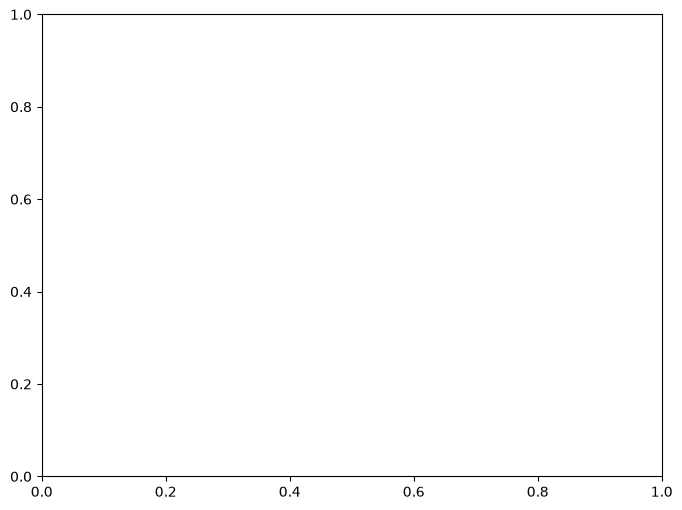

In [45]:
trainer = ModelTrainer(
    cv=tscv,
    scoring="f1",
    n_jobs=-1
)

evaluator = ModelEvaluator()

comparator = ModelComparator()

roc_plotter = ROCCurvePlotter()


# Entrenar los modelos

In [46]:
trained_models = []

print(
    "\n--- INICIANDO MODELADO DE LÍNEA BASE ---"
)

for model in modelos:

    trained_model = trainer.fit(
        model,
        X_train,
        y_train
    )

    trained_models.append(
        trained_model
    )

    print(
        f"✓ {model.get_name()} "
        f"entrenado en "
        f"{trained_model['train_time']} segundos"
    )



--- INICIANDO MODELADO DE LÍNEA BASE ---
Procesando: Regresion Logistica...
✓ Regresion Logistica entrenado en 0.23 segundos
Procesando: Random Forest...
✓ Random Forest entrenado en 2.89 segundos
Procesando: XGBoost...
✓ XGBoost entrenado en 1.09 segundos
Procesando: Red Neuronal (MLP)...
✓ Red Neuronal (MLP) entrenado en 4.35 segundos


# Ver los mejores hiperparámetros

In [47]:
for trained_model in trained_models:

    print(
        f"\n{trained_model['model'].get_name()}"
    )

    print(
        "Mejores hiperparámetros:"
    )

    print(
        trained_model["best_params"]
    )



Regresion Logistica
Mejores hiperparámetros:
{'clf__C': 1.0, 'clf__solver': 'lbfgs'}

Random Forest
Mejores hiperparámetros:
{'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}

XGBoost
Mejores hiperparámetros:
{'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__n_estimators': 100}

Red Neuronal (MLP)
Mejores hiperparámetros:
{'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (32, 16)}


# Evaluar los modelos sobre 2024

In [48]:
resultados = []

print(
    "\n--- EVALUACIÓN SOBRE VALIDACIÓN 2024 ---"
)

for trained_model in trained_models:

    result = evaluator.evaluate(
        trained_model,
        X_val,
        y_val
    )

    resultados.append(result)

    comparator.add_result(
        result
    )

    roc_plotter.add_model(
        trained_model,
        X_val,
        y_val
    )

    print(
        f"\nModelo: {result['Modelo']}"
    )

    print(
        f"Accuracy:  {result['Accuracy']}"
    )

    print(
        f"Precision: {result['Precision']}"
    )

    print(
        f"Recall:    {result['Recall']}"
    )

    print(
        f"F1-Score:  {result['F1-Score']}"
    )

    print(
        f"ROC-AUC:   {result['ROC-AUC']}"
    )



--- EVALUACIÓN SOBRE VALIDACIÓN 2024 ---

Modelo: Regresion Logistica
Accuracy:  0.9545
Precision: 0.7059
Recall:    0.2143
F1-Score:  0.3288
ROC-AUC:   0.8277

Modelo: Random Forest
Accuracy:  0.8098
Precision: 0.1366
Recall:    0.5
F1-Score:  0.2146
ROC-AUC:   0.7462

Modelo: XGBoost
Accuracy:  0.8024
Precision: 0.1133
Recall:    0.4107
F1-Score:  0.1776
ROC-AUC:   0.6695

Modelo: Red Neuronal (MLP)
Accuracy:  0.949
Precision: 0.5143
Recall:    0.3214
F1-Score:  0.3956
ROC-AUC:   0.769


# Tabla comparativa

In [49]:
df_resultados = comparator.get_results()

df_resultados


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Tiempo (s),Hiperparametros Optimos
3,Red Neuronal (MLP),0.9490,0.5143,0.3214,0.3956,0.7690,4.35,"{'clf__alpha': 0.0001, 'clf__hidden_layer_size..."
0,Regresion Logistica,0.9545,0.7059,0.2143,0.3288,0.8277,0.23,"{'clf__C': 1.0, 'clf__solver': 'lbfgs'}"
1,Random Forest,0.8098,0.1366,0.5000,0.2146,0.7462,2.89,"{'clf__max_depth': None, 'clf__min_samples_spl..."
2,XGBoost,0.8024,0.1133,0.4107,0.1776,0.6695,1.09,"{'clf__learning_rate': 0.1, 'clf__max_depth': ..."


# Mostrar únicamente las métricas principales

In [50]:
df_metricas = df_resultados[
    [
        "Modelo",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Tiempo (s)"
    ]
]

df_metricas


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Tiempo (s)
3,Red Neuronal (MLP),0.9490,0.5143,0.3214,0.3956,0.7690,4.35
0,Regresion Logistica,0.9545,0.7059,0.2143,0.3288,0.8277,0.23
1,Random Forest,0.8098,0.1366,0.5000,0.2146,0.7462,2.89
2,XGBoost,0.8024,0.1133,0.4107,0.1776,0.6695,1.09


# Mostrar hiperparámetros

In [51]:
df_hiperparametros = df_resultados[
    [
        "Modelo",
        "Hiperparametros Optimos"
    ]
]

df_hiperparametros


,Modelo,Hiperparametros Optimos
3,Red Neuronal (MLP),"{'clf__alpha': 0.0001, 'clf__hidden_layer_size..."
0,Regresion Logistica,"{'clf__C': 1.0, 'clf__solver': 'lbfgs'}"
1,Random Forest,"{'clf__max_depth': None, 'clf__min_samples_spl..."
2,XGBoost,"{'clf__learning_rate': 0.1, 'clf__max_depth': ..."


# Curvas ROC

In [52]:
roc_path = results_dir / "curvas_roc_7_4.png"

roc_plotter.save(
    roc_path
)

print(
    f"Curvas ROC guardadas en: {roc_path}"
)


Curvas ROC guardadas en: c:\Users\LENOVO\Desktop\dna_project\results\curvas_roc_7_4.png


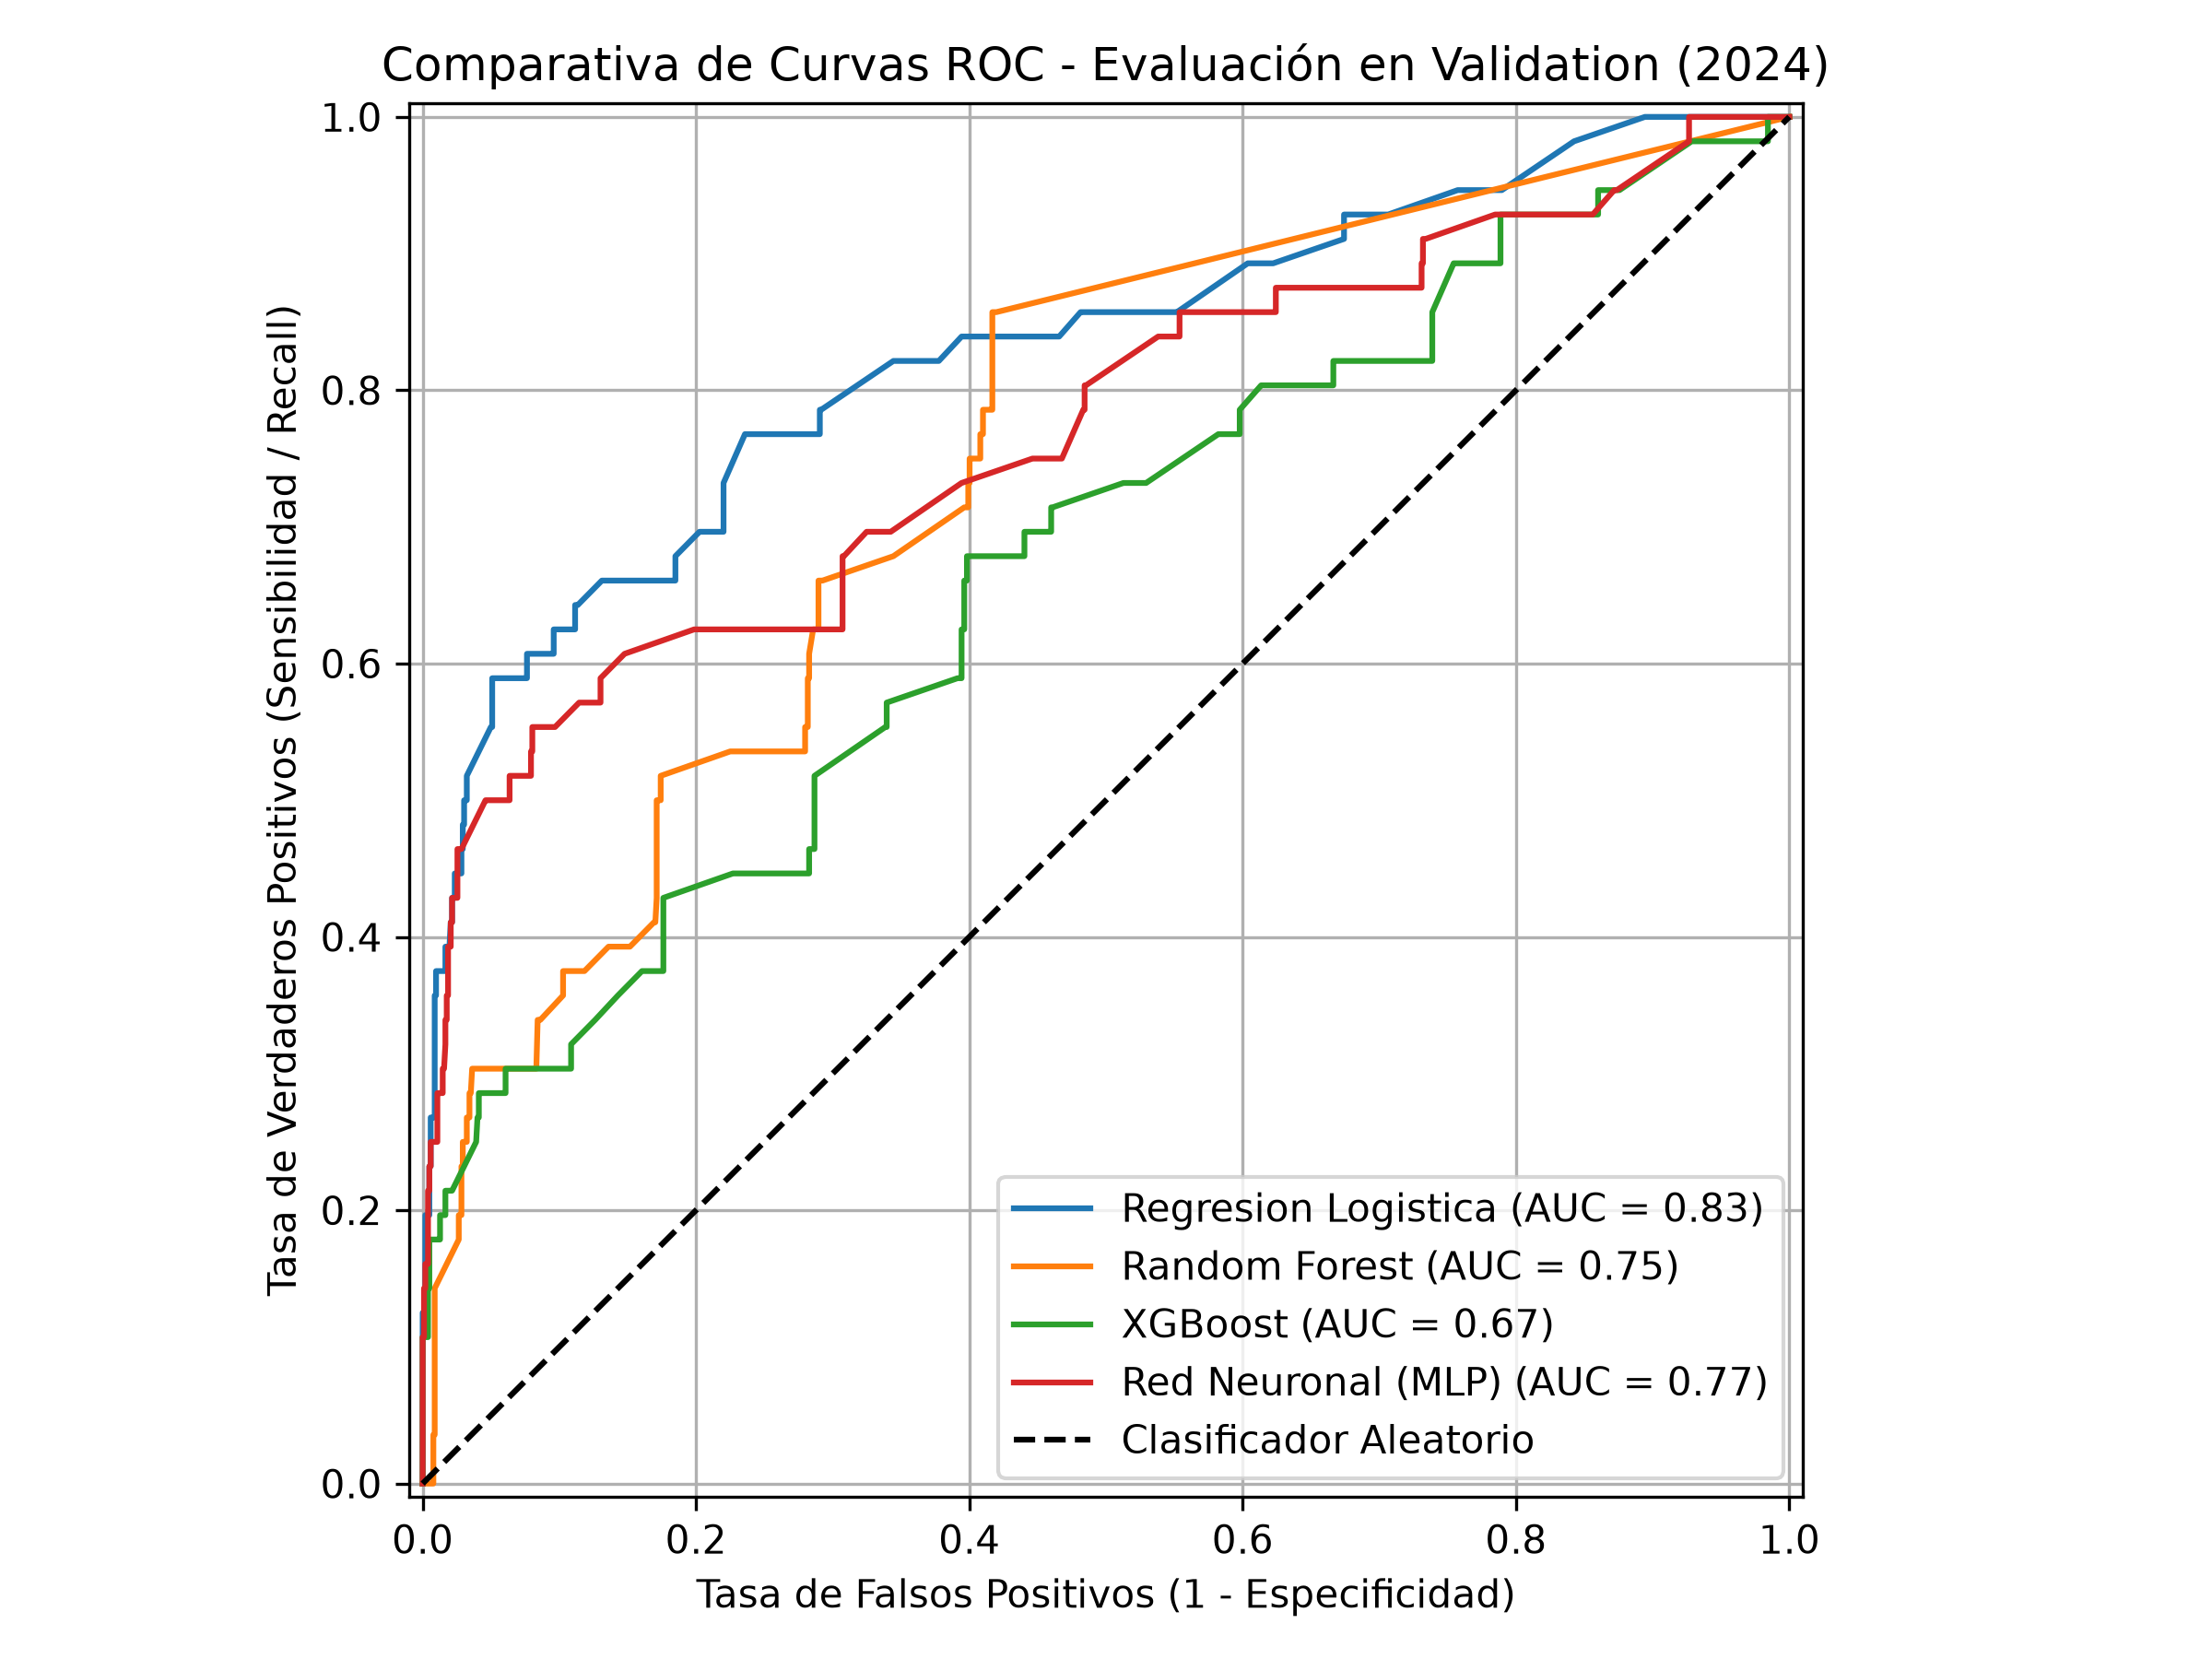

In [53]:
from IPython.display import Image, display

display(
    Image(
        filename=str(roc_path)
    )
)

# Guardar resultados CSV

In [54]:
csv_path = (
    results_dir /
    "resultados_modelado_7_4.csv"
)

comparator.save_results(
    csv_path
)

print(
    f"Resultados guardados en: {csv_path}"
)


Resultados guardados en: c:\Users\LENOVO\Desktop\dna_project\results\resultados_modelado_7_4.csv


# Resumen final

In [55]:
print("=" * 85)
print("RESUMEN FINAL DEL MODELADO")
print("=" * 85)

display(
    df_metricas
)


RESUMEN FINAL DEL MODELADO


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Tiempo (s)
3,Red Neuronal (MLP),0.9490,0.5143,0.3214,0.3956,0.7690,4.35
0,Regresion Logistica,0.9545,0.7059,0.2143,0.3288,0.8277,0.23
1,Random Forest,0.8098,0.1366,0.5000,0.2146,0.7462,2.89
2,XGBoost,0.8024,0.1133,0.4107,0.1776,0.6695,1.09


In [56]:
print("=" * 85)
print("HIPERPARÁMETROS OPTIMIZADOS")
print("=" * 85)

display(
    df_hiperparametros
)


HIPERPARÁMETROS OPTIMIZADOS


,Modelo,Hiperparametros Optimos
3,Red Neuronal (MLP),"{'clf__alpha': 0.0001, 'clf__hidden_layer_size..."
0,Regresion Logistica,"{'clf__C': 1.0, 'clf__solver': 'lbfgs'}"
1,Random Forest,"{'clf__max_depth': None, 'clf__min_samples_spl..."
2,XGBoost,"{'clf__learning_rate': 0.1, 'clf__max_depth': ..."
